In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

data_path = r"C:\Users\dhire\OneDrive\Desktop\openpmx\data"

print("Ready!")

Ready!


In [1]:
import os

# Point to the data folder
data_path = r"C:\Users\dhire\OneDrive\Desktop\openpmx\data"

# See what's inside
for folder in os.listdir(data_path):
    print(folder)

1st_test
2nd_test
3rd_test
Readme Document for IMS Bearing Data.pdf


In [2]:
# Look inside the first folder
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"\nFolder: {folder}")
        print(f"Number of files: {len(files)}")
        print(f"First few files: {files[:3]}")


Folder: 1st_test
Number of files: 1
First few files: ['1st_test']

Folder: 2nd_test
Number of files: 1
First few files: ['2nd_test']

Folder: 3rd_test
Number of files: 1
First few files: ['4th_test']


In [3]:
# Go one level deeper
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_path):
        # Go inside the nested folder
        inner_path = os.path.join(folder_path, folder)
        if os.path.exists(inner_path):
            files = os.listdir(inner_path)
            print(f"\nFolder: {folder}")
            print(f"Number of files: {len(files)}")
            print(f"First few files: {files[:3]}")
            print(f"Last few files: {files[-3:]}")


Folder: 1st_test
Number of files: 2156
First few files: ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13']
Last few files: ['2003.11.25.23.19.56', '2003.11.25.23.29.56', '2003.11.25.23.39.56']

Folder: 2nd_test
Number of files: 984
First few files: ['2004.02.12.10.32.39', '2004.02.12.10.42.39', '2004.02.12.10.52.39']
Last few files: ['2004.02.19.06.02.39', '2004.02.19.06.12.39', '2004.02.19.06.22.39']


In [7]:
# Load one data file and see what's inside
first_folder = os.path.join(data_path, "1st_test", "1st_test")
first_file = os.path.join(first_folder, "2003.10.22.12.06.24")

# Load it
df = pd.read_csv(first_file, sep="\t", header=None)

print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])
print("\nFirst 5 rows:")
print(df.head())

Number of columns: 8
Number of rows: 20480

First 5 rows:
       0      1      2      3      4      5      6      7
0 -0.022 -0.039 -0.183 -0.054 -0.105 -0.134 -0.129 -0.142
1 -0.105 -0.017 -0.164 -0.183 -0.049  0.029 -0.115 -0.122
2 -0.183 -0.098 -0.195 -0.125 -0.005 -0.007 -0.171 -0.071
3 -0.178 -0.161 -0.159 -0.178 -0.100 -0.115 -0.112 -0.078
4 -0.208 -0.129 -0.261 -0.098 -0.151 -0.205 -0.063 -0.066


In [8]:
# Load with correct column names
first_folder = os.path.join(data_path, "1st_test", "1st_test")
first_file = os.path.join(first_folder, "2003.10.22.12.06.24")

df = pd.read_csv(first_file, sep="\t", header=None)
df.columns = [
    "Bearing1_CH1", "Bearing1_CH2",
    "Bearing2_CH1", "Bearing2_CH2",
    "Bearing3_CH1", "Bearing3_CH2",
    "Bearing4_CH1", "Bearing4_CH2"
]

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

Shape: (20480, 8)

First 5 rows:
   Bearing1_CH1  Bearing1_CH2  Bearing2_CH1  Bearing2_CH2  Bearing3_CH1  \
0        -0.022        -0.039        -0.183        -0.054        -0.105   
1        -0.105        -0.017        -0.164        -0.183        -0.049   
2        -0.183        -0.098        -0.195        -0.125        -0.005   
3        -0.178        -0.161        -0.159        -0.178        -0.100   
4        -0.208        -0.129        -0.261        -0.098        -0.151   

   Bearing3_CH2  Bearing4_CH1  Bearing4_CH2  
0        -0.134        -0.129        -0.142  
1         0.029        -0.115        -0.122  
2        -0.007        -0.171        -0.071  
3        -0.115        -0.112        -0.078  
4        -0.205        -0.063        -0.066  

Basic statistics:
       Bearing1_CH1  Bearing1_CH2  Bearing2_CH1  Bearing2_CH2  Bearing3_CH1  \
count  20480.000000   20480.00000  20480.000000  20480.000000  20480.000000   
mean      -0.094593      -0.09388     -0.093817     -0.093752  

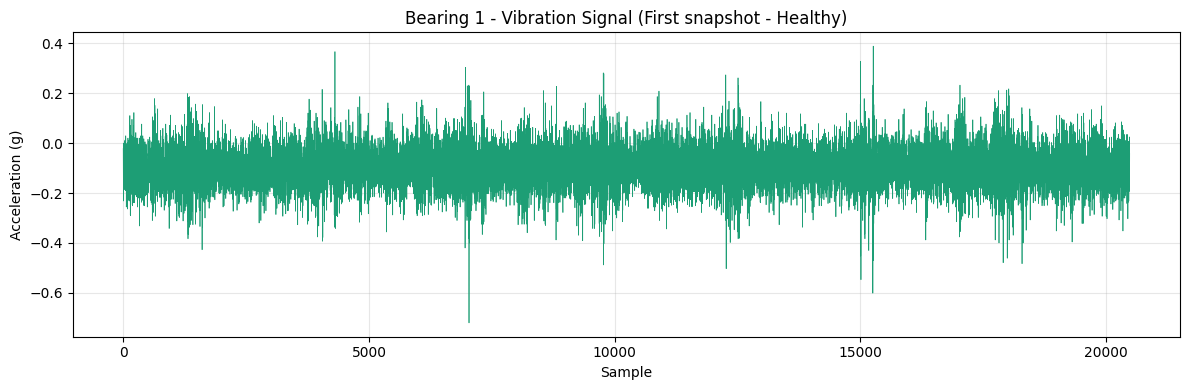

In [9]:
# Plot the vibration signal for Bearing 1
plt.figure(figsize=(12, 4))
plt.plot(df["Bearing1_CH1"], color="#1D9E75", linewidth=0.5)
plt.title("Bearing 1 - Vibration Signal (First snapshot - Healthy)")
plt.xlabel("Sample")
plt.ylabel("Acceleration (g)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

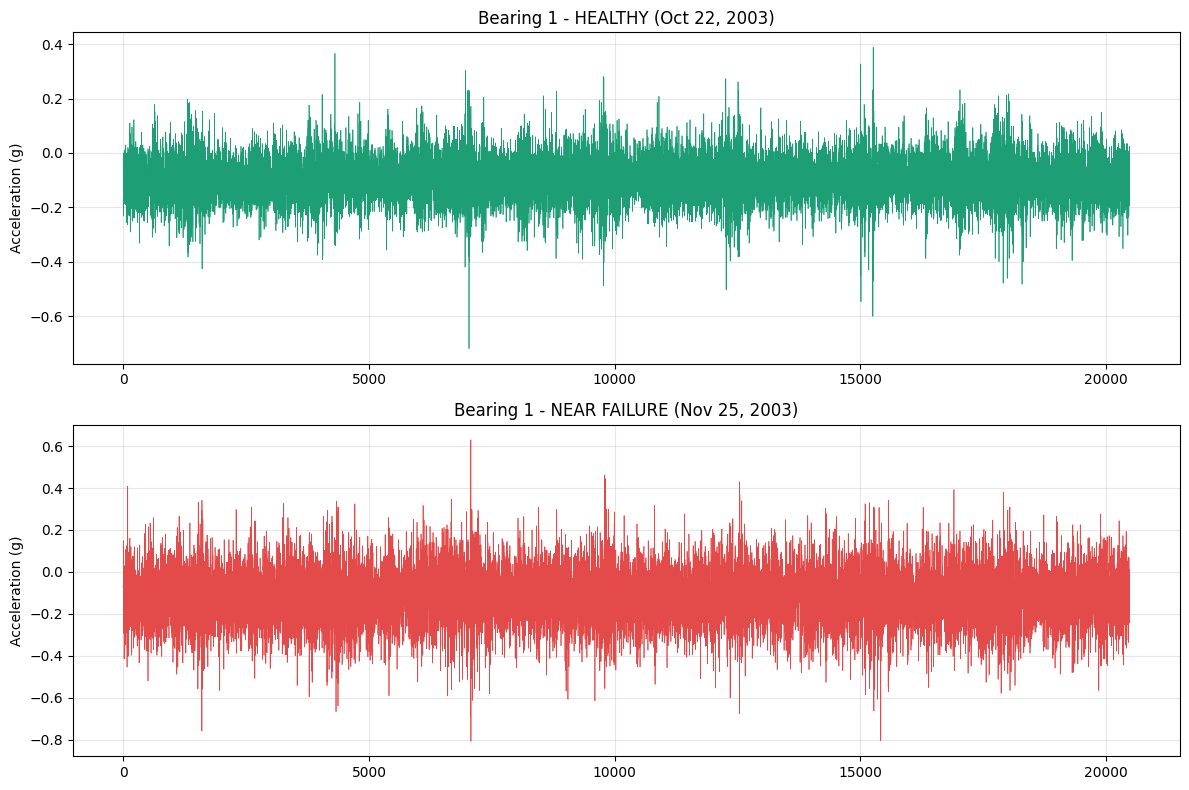


Healthy max vibration: 0.7200 g
Failed max vibration:  0.8080 g


In [10]:
# Load the LAST file - right before bearing failure
last_file = os.path.join(first_folder, "2003.11.25.23.39.56")

df_failed = pd.read_csv(last_file, sep="\t", header=None)
df_failed.columns = [
    "Bearing1_CH1", "Bearing1_CH2",
    "Bearing2_CH1", "Bearing2_CH2",
    "Bearing3_CH1", "Bearing3_CH2",
    "Bearing4_CH1", "Bearing4_CH2"
]

# Plot healthy vs failed side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Healthy
axes[0].plot(df["Bearing1_CH1"], color="#1D9E75", linewidth=0.5)
axes[0].set_title("Bearing 1 - HEALTHY (Oct 22, 2003)")
axes[0].set_ylabel("Acceleration (g)")
axes[0].grid(True, alpha=0.3)

# Failed
axes[1].plot(df_failed["Bearing1_CH1"], color="#E24B4A", linewidth=0.5)
axes[1].set_title("Bearing 1 - NEAR FAILURE (Nov 25, 2003)")
axes[1].set_ylabel("Acceleration (g)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nHealthy max vibration: {df['Bearing1_CH1'].abs().max():.4f} g")
print(f"Failed max vibration:  {df_failed['Bearing1_CH1'].abs().max():.4f} g")

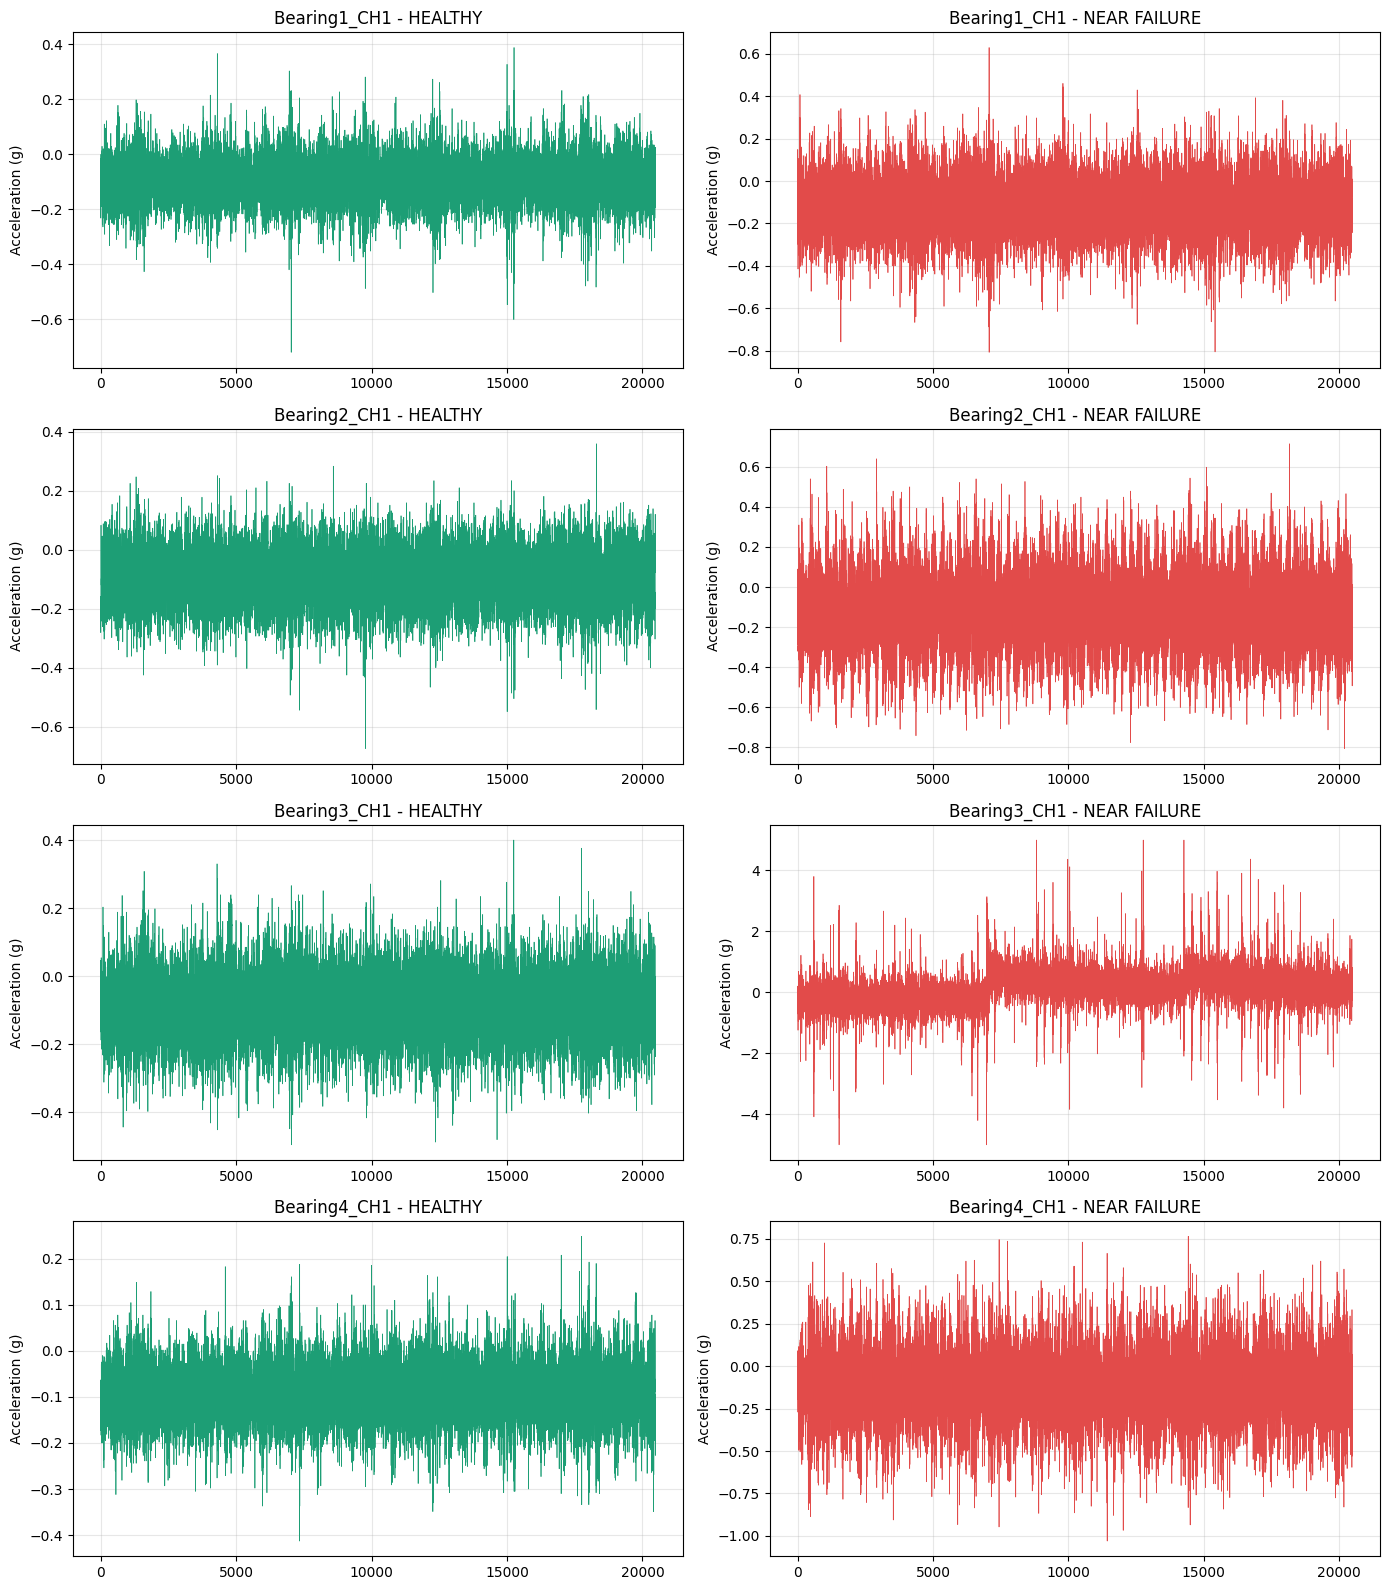

Maximum vibration comparison:
----------------------------------------
Bearing1_CH1: 0.7200g → 0.8080g (12.2% increase)
Bearing2_CH1: 0.6740g → 0.8060g (19.6% increase)
Bearing3_CH1: 0.4960g → 5.0000g (908.1% increase)
Bearing4_CH1: 0.4130g → 1.0300g (149.4% increase)


In [11]:
# Compare all 4 bearings - healthy vs failed
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

bearings = ["Bearing1_CH1", "Bearing2_CH1", "Bearing3_CH1", "Bearing4_CH1"]

for i, bearing in enumerate(bearings):
    # Healthy
    axes[i, 0].plot(df[bearing], color="#1D9E75", linewidth=0.5)
    axes[i, 0].set_title(f"{bearing} - HEALTHY")
    axes[i, 0].set_ylabel("Acceleration (g)")
    axes[i, 0].grid(True, alpha=0.3)
    
    # Failed
    axes[i, 1].plot(df_failed[bearing], color="#E24B4A", linewidth=0.5)
    axes[i, 1].set_title(f"{bearing} - NEAR FAILURE")
    axes[i, 1].set_ylabel("Acceleration (g)")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print max vibration for each bearing
print("Maximum vibration comparison:")
print("-" * 40)
for bearing in bearings:
    healthy_max = df[bearing].abs().max()
    failed_max = df_failed[bearing].abs().max()
    increase = ((failed_max - healthy_max) / healthy_max) * 100
    print(f"{bearing}: {healthy_max:.4f}g → {failed_max:.4f}g ({increase:.1f}% increase)")

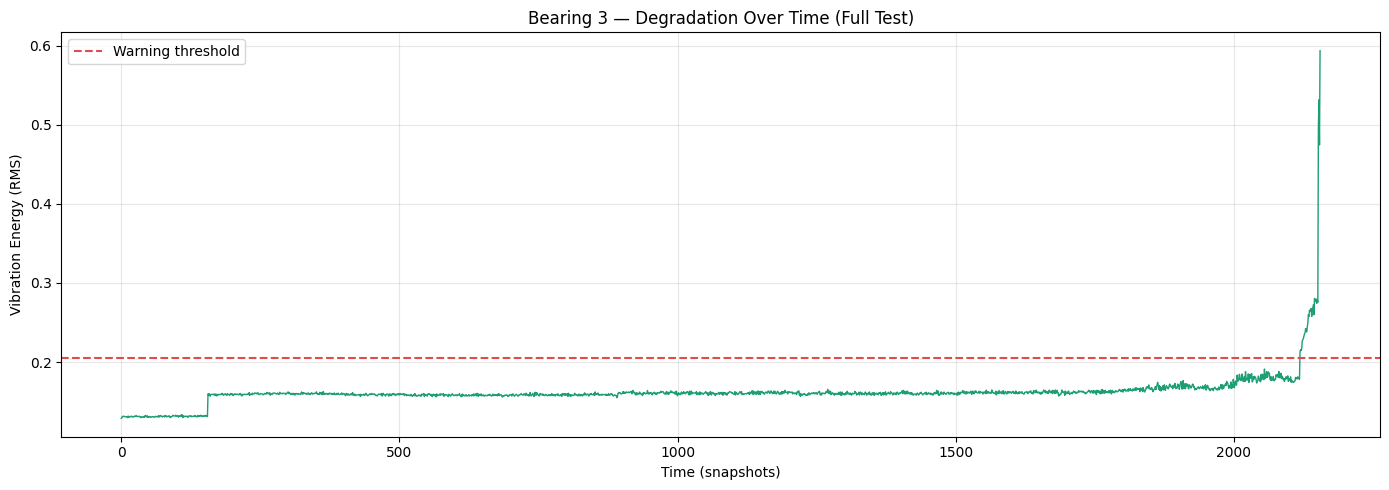

Total snapshots: 2156
Normal RMS: 0.1311g
Final RMS: 0.5936g
Warning threshold: 0.2053g


In [14]:
# Track Bearing 3 degradation across ALL files over time
first_folder = os.path.join(data_path, "1st_test", "1st_test")
all_files = sorted(os.listdir(first_folder))

# Calculate RMS (Root Mean Square) for each snapshot
# RMS is the standard way to measure vibration energy
rms_values = []
timestamps = []

for i, file in enumerate(all_files):
    file_path = os.path.join(first_folder, file)
    data = pd.read_csv(file_path, sep="\t", header=None)
    rms = np.sqrt(np.mean(data.iloc[:, 4]**2))  # Bearing 3 CH1
    rms_values.append(rms)
    timestamps.append(i)

# Plot the degradation curve
plt.figure(figsize=(14, 5))
plt.plot(timestamps, rms_values, color="#1D9E75", linewidth=1)
plt.axhline(y=np.mean(rms_values) + 2*np.std(rms_values), 
            color="#E24B4A", linestyle="--", label="Warning threshold")
plt.title("Bearing 3 — Degradation Over Time (Full Test)")
plt.xlabel("Time (snapshots)")
plt.ylabel("Vibration Energy (RMS)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total snapshots: {len(rms_values)}")
print(f"Normal RMS: {np.mean(rms_values[:100]):.4f}g")
print(f"Final RMS: {rms_values[-1]:.4f}g")
print(f"Warning threshold: {np.mean(rms_values) + 2*np.std(rms_values):.4f}g")